## Generate visual of bad localization

3310


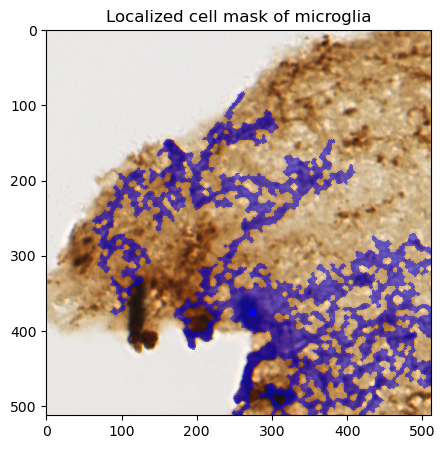

In [4]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from torch.utils.data import DataLoader
import pyvips
from pathlib import Path
import random
import matplotlib.pyplot as plt
random.seed(25)
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from skan import draw, Skeleton
import pyvips
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from scripts.filters import *
from scripts.utils import *
from extract_features import * 
pyvips.cache_set_max_mem(500 * 1024 * 1024)
pyvips.cache_set_max(0)

def extract_bbs_centroids(file_path, results):
    file = pd.read_parquet(file_path)
    for index, r in file.iterrows():
        x1, y1, x2, y2 = r["x1"], r["y1"], r["x2"], r["y2"]
        results.append({"x1":int(x1),"y1":int(y1),"x2":int(x2),"y2":int(y2),"cx":int(r["cx"]),"cy":int(r["cy"])})

    return results
    

IMAGE_DIR = "/mnt/d/microglia_data"
imgs = [f for f in Path(IMAGE_DIR).glob("./*.tiff")]
PARQUET_DIR = "../cell_localization/clustered_bboxes"
parquet = [f for f in Path(PARQUET_DIR).glob("./*.parquet")]

indices = [0,9,2,3,4,11,10,7,8,5,6,1]
parquets = [parquet[i] for i in indices]
df = pd.read_parquet("../cell_classification/results/new2/microglia_region_split.parquet")

idx = 4
file = imgs[idx]
from skimage.morphology import skeletonize, convex_hull_image
from skimage.filters import threshold_multiotsu

def skeleton_length_corrected(skeleton):
    skel = (skeleton > 0).astype(np.uint8)
    
    straight = np.array([[0,1,0],[1,0,1],[0,1,0]])
    diagonal = np.array([[1,0,1],[0,0,0],[1,0,1]])
    
    straight_count = cv2.filter2D(skel.astype(np.float32), -1, straight)
    diag_count     = cv2.filter2D(skel.astype(np.float32), -1, diagonal)
    
    length = (np.sum(skel * straight_count) * 0.5 + np.sum(skel * diag_count) * np.sqrt(2) * 0.5)
    return length


embs = []
for _, r in df[df["slide"]=="TPO_63_TPO"].iterrows():
    x1, y1, x2, y2,cx,cy = r["x1"], r["y1"], r["x2"], r["y2"], r["cx"], r["cy"]
    embs.append({"x1":int(x1),"y1":int(y1),"x2":int(x2),"y2":int(y2),"cx":int(cx),"cy":int(cy)})
df = df[df["slide"]=="TPO_63_TPO"]
df["abs_cx"] = (df["x1"] + df["cx"]).astype(int)
df["abs_cy"] = (df["y1"] + df["cy"]).astype(int)
from scipy.spatial import cKDTree

tree = cKDTree(df[["abs_cx", "abs_cy"]].to_numpy())
vips_img = pyvips.Image.new_from_file(str(file), access="random")
for i in range(2,3):

    row = embs[i]
    cropped = vips_img.crop(row["x1"], row["y1"], row["x2"] - row["x1"], row["y2"] - row["y1"])
    patch = np.ndarray(
        buffer=cropped.write_to_memory(),
        dtype=np.uint8,
        shape=[cropped.height, cropped.width, cropped.bands],
    )  

    x1, y1, x2, y2 = map(int, (row["x1"], row["y1"], row["x2"], row["y2"]))
    cx_local, cy_local = int(row["cx"]), int(row["cy"])
    cx_abs = x1 + cx_local
    cy_abs = y1 + cy_local
    H, W = patch.shape[:2]

    idx = tree.query_ball_point([(cx_abs, cy_abs)], r=max(H, W))[0]
    neighbors = df.iloc[idx]

    soma = binarize_soma_dab(patch, (row["cx"], row["cy"]))
    print(np.count_nonzero(soma))
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    skeleton = extract_skeleton(thresh, soma)
    cell_mask = extract_cell_mask_from_skeleton(thresh, skeleton)

    skel_binary = skeleton > 0
    skeleton_length = skeleton_length_corrected(skeleton)

    cha_mask = convex_hull_image(thresh > 0)
    hull_diameter = np.sqrt(np.count_nonzero(cha_mask))
    tortuosity = skeleton_length / hull_diameter if hull_diameter > 0 else 0

    dist = ndimage.distance_transform_edt(cell_mask > 0)
    skel_pixels = skel_binary & (cell_mask > 0)
    mean_thickness = dist[skel_pixels].mean() * 2 if skel_pixels.any() else 0
    max_thickness  = dist[skel_pixels].max()  * 2 if skel_pixels.any() else 0

    sk_obj = Skeleton(skeleton)
    branch_lengths = sk_obj.path_lengths()
    mean_branch_length = branch_lengths.mean() if len(branch_lengths) > 0 else 0
    max_branch_length  = branch_lengths.max()  if len(branch_lengths) > 0 else 0
    n_branches = len(branch_lengths)

  
    from skimage.filters import frangi, meijering, sato, hessian
    import matplotlib.pyplot as plt
    from skimage import io, color, exposure
    from skimage.filters import meijering, threshold_otsu
    from skimage.morphology import skeletonize
    img_rescaled = exposure.equalize_adapthist(gray)


    ridge_map = meijering(img_rescaled, sigmas=range(1, 5), black_ridges=True)

    thresh = threshold_otsu(ridge_map)
    binary_map = ridge_map > thresh


    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.ndimage import distance_transform_edt
    from skimage.morphology import binary_dilation, disk

 
    soma_bool = soma > 0
    soma_distances, nearest_soma_idx = distance_transform_edt(~soma_bool, return_indices=True)    
    valid_processes = binary_map & (soma_distances <= 15)
    
    bridges = np.zeros_like(binary_map, dtype=bool)
    
    proc_y, proc_x = np.where(valid_processes)
    

    if len(proc_y) > 0:
        target_y = nearest_soma_idx[0, proc_y, proc_x]
        target_x = nearest_soma_idx[1, proc_y, proc_x]
        

        from skimage.draw import line
        for py, px, ty, tx in zip(proc_y, proc_x, target_y, target_x):
            rr, cc = line(py, px, ty, tx)
            bridges[rr, cc] = True
            
    full_cell_mask = binary_map | bridges | soma
    
    from skimage.morphology import binary_closing
    from skimage import morphology, filters, measure
    from scipy import ndimage
    import numpy as np
    full_cell_mask = binary_closing(full_cell_mask, disk(2))
    cleaned = morphology.remove_small_objects(full_cell_mask, min_size=50)
    
    smoothed = morphology.binary_closing(cleaned, morphology.disk(3))
    smoothed = morphology.binary_opening(smoothed, morphology.disk(2))

    from scipy.ndimage import distance_transform_edt
    from skimage.segmentation import watershed
    from skimage.morphology import skeletonize
    from scipy.spatial import cKDTree

    markers = np.zeros((H, W), dtype=np.int32)
    target_idx = None

    for local_idx, nrow in enumerate(neighbors.itertuples(index=False), start=1):
        lx = int(nrow.abs_cx) - x1
        ly = int(nrow.abs_cy) - y1

        if 0 <= lx < W and 0 <= ly < H:
            markers[ly, lx] = local_idx

            if int(nrow.abs_cx) == cx_abs and int(nrow.abs_cy) == cy_abs:
                target_idx = local_idx

    if target_idx is None:
        print(f"Skipping row {i}: target centroid not found in crop")
        continue

    dist = distance_transform_edt(smoothed)
    territory = watershed(-dist, markers=markers, mask=smoothed > 0)
    smoothed = (territory == target_idx)
    skeleton = skeletonize(smoothed)

    radii, counts, soma_radius = sholl_analysis_soma(skeleton, soma, (row["cx"], row["cy"]))

    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import numpy as np

    fig, (ax0) = plt.subplots(1, 1, figsize=(12, 5))
    fig.subplots_adjust(wspace=0.05)
    # ax3.imshow(patch)

    overlay = np.zeros((*smoothed.shape, 4), dtype=np.float32)
    overlay[smoothed > 0] = [0.0, 0.0, 1.0, 0.5]

    

    ax0.imshow(patch)


    # draw.overlay_skeleton_2d_class(
    #     Skeleton(skeleton),
    #     skeleton_colormap="viridis_r",
    #     vmin=0,
    #     axes=ax0,
    # )

    ax0.scatter(cx_local, cy_local, s=20, c="blue")
    ax0.set_title("Skeleton and Sholl analysis")

    H, W = patch.shape[:2]
    # for ax in (ax0):
    ax0.set_xlim(0, W)
    ax0.set_ylim(H, 0)
    ax0.set_aspect("equal")

    ax0.imshow(overlay, interpolation="nearest")
    # ax3.set_title("Localized microglia")
    ax0.set_title("Localized cell mask of microglia")

    # plt.tight_layout()
    plt.savefig("./feature_calc_neg_ex.pdf", dpi=300,bbox_inches='tight')
    plt.show()


    


## Generate visual of feature extraction

2765
skeleton pixels: 3951


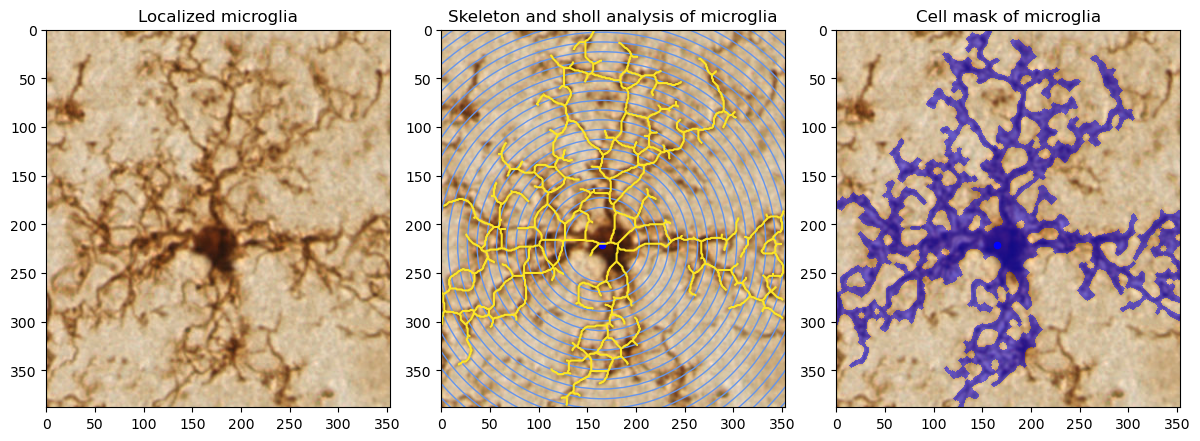

In [14]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from torch.utils.data import DataLoader
import pyvips
from pathlib import Path
import random
import matplotlib.pyplot as plt
random.seed(25)
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from skan import draw, Skeleton
import pyvips
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import pandas as pd
from scripts.filters import *
from scripts.utils import *
from extract_features import * 
pyvips.cache_set_max_mem(500 * 1024 * 1024)
pyvips.cache_set_max(0)

def extract_bbs_centroids(file_path, results):
    file = pd.read_parquet(file_path)
    for index, r in file.iterrows():
        x1, y1, x2, y2 = r["x1"], r["y1"], r["x2"], r["y2"]
        results.append({"x1":int(x1),"y1":int(y1),"x2":int(x2),"y2":int(y2),"cx":int(r["cx"]),"cy":int(r["cy"])})

    return results
    

IMAGE_DIR = "/mnt/d/microglia_data"
imgs = [f for f in Path(IMAGE_DIR).glob("./*.tiff")]
PARQUET_DIR = "../cell_localization/clustered_bboxes"
parquet = [f for f in Path(PARQUET_DIR).glob("./*.parquet")]

indices = [0,9,2,3,4,11,10,7,8,5,6,1]
parquets = [parquet[i] for i in indices]
df = pd.read_parquet("../cell_classification/results/new2/microglia_region_split.parquet")

idx = 1
file = imgs[idx]
from skimage.morphology import skeletonize, convex_hull_image
from skimage.filters import threshold_multiotsu

def skeleton_length_corrected(skeleton):
    skel = (skeleton > 0).astype(np.uint8)
    
    straight = np.array([[0,1,0],[1,0,1],[0,1,0]])
    diagonal = np.array([[1,0,1],[0,0,0],[1,0,1]])
    
    straight_count = cv2.filter2D(skel.astype(np.float32), -1, straight)
    diag_count     = cv2.filter2D(skel.astype(np.float32), -1, diagonal)
    
    length = (np.sum(skel * straight_count) * 0.5 + np.sum(skel * diag_count) * np.sqrt(2) * 0.5)
    return length


embs = []
for _, r in df[df["slide"]=="TPO_61_EV"].iterrows():
    x1, y1, x2, y2,cx,cy = r["x1"], r["y1"], r["x2"], r["y2"], r["cx"], r["cy"]
    embs.append({"x1":int(x1),"y1":int(y1),"x2":int(x2),"y2":int(y2),"cx":int(cx),"cy":int(cy)})
df = df[df["slide"]=="TPO_61_EV"]
df["abs_cx"] = (df["x1"] + df["cx"]).astype(int)
df["abs_cy"] = (df["y1"] + df["cy"]).astype(int)
from scipy.spatial import cKDTree

# build tree in GLOBAL coordinates
tree = cKDTree(df[["abs_cx", "abs_cy"]].to_numpy())
vips_img = pyvips.Image.new_from_file(str(file), access="random")
for i in range(447,448):

    row = embs[i]
    cropped = vips_img.crop(row["x1"], row["y1"], row["x2"] - row["x1"], row["y2"] - row["y1"])
    patch = np.ndarray(
        buffer=cropped.write_to_memory(),
        dtype=np.uint8,
        shape=[cropped.height, cropped.width, cropped.bands],
    )  
    def sholl_decay(radii, counts):
        valid = counts > 0
        if valid.sum() < 3:
            return 0
        slope, _ = np.polyfit(radii[valid], np.log(counts[valid] + 1), 1)
        return slope
    x1, y1, x2, y2 = map(int, (row["x1"], row["y1"], row["x2"], row["y2"]))
    cx_local, cy_local = int(row["cx"]), int(row["cy"])
    cx_abs = x1 + cx_local
    cy_abs = y1 + cy_local
    H, W = patch.shape[:2]

    idx = tree.query_ball_point([(cx_abs, cy_abs)], r=max(H, W))[0]
    neighbors = df.iloc[idx]

    soma = binarize_soma_dab(patch, (row["cx"], row["cy"]))
    print(np.count_nonzero(soma))
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    skeleton = extract_skeleton(thresh, soma)
    cell_mask = extract_cell_mask_from_skeleton(thresh, skeleton)

    skel_binary = skeleton > 0
    skeleton_length = skeleton_length_corrected(skeleton)

    cha_mask = convex_hull_image(thresh > 0)  # use thresh, not patch
    hull_diameter = np.sqrt(np.count_nonzero(cha_mask))
    tortuosity = skeleton_length / hull_diameter if hull_diameter > 0 else 0

    dist = ndimage.distance_transform_edt(cell_mask > 0)
    skel_pixels = skel_binary & (cell_mask > 0)
    mean_thickness = dist[skel_pixels].mean() * 2 if skel_pixels.any() else 0
    max_thickness  = dist[skel_pixels].max()  * 2 if skel_pixels.any() else 0

    sk_obj = Skeleton(skeleton)
    branch_lengths = sk_obj.path_lengths()
    mean_branch_length = branch_lengths.mean() if len(branch_lengths) > 0 else 0
    max_branch_length  = branch_lengths.max()  if len(branch_lengths) > 0 else 0
    n_branches = len(branch_lengths)

    # radii, counts = sholl_analysis_soma(skeleton, soma)

  
    from skimage.filters import frangi, meijering, sato, hessian
    import matplotlib.pyplot as plt
    from skimage import io, color, exposure
    from skimage.filters import meijering, threshold_otsu
    from skimage.morphology import skeletonize
    img_rescaled = exposure.equalize_adapthist(gray)


    ridge_map = meijering(img_rescaled, sigmas=range(1, 5), black_ridges=True)

    thresh = threshold_otsu(ridge_map)
    binary_map = ridge_map > thresh


    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.ndimage import distance_transform_edt
    from skimage.morphology import binary_dilation, disk

 
    soma_bool = soma > 0
    soma_distances, nearest_soma_idx = distance_transform_edt(~soma_bool, return_indices=True)    
    valid_processes = binary_map & (soma_distances <= 15)
    
    bridges = np.zeros_like(binary_map, dtype=bool)
    
    proc_y, proc_x = np.where(valid_processes)
    

    if len(proc_y) > 0:
        target_y = nearest_soma_idx[0, proc_y, proc_x]
        target_x = nearest_soma_idx[1, proc_y, proc_x]
        

        from skimage.draw import line
        for py, px, ty, tx in zip(proc_y, proc_x, target_y, target_x):
            rr, cc = line(py, px, ty, tx)
            bridges[rr, cc] = True
            
    full_cell_mask = binary_map | bridges | soma
    
    from skimage.morphology import binary_closing
    from skimage import morphology, filters, measure
    from scipy import ndimage
    import numpy as np
    full_cell_mask = binary_closing(full_cell_mask, disk(2))
    cleaned = morphology.remove_small_objects(full_cell_mask, min_size=50)
    
    smoothed = morphology.binary_closing(cleaned, morphology.disk(3))
    smoothed = morphology.binary_opening(smoothed, morphology.disk(2))

    from scipy.ndimage import distance_transform_edt
    from skimage.segmentation import watershed
    from skimage.morphology import skeletonize
    from scipy.spatial import cKDTree

    markers = np.zeros((H, W), dtype=np.int32)
    target_idx = None

    for local_idx, nrow in enumerate(neighbors.itertuples(index=False), start=1):
        lx = int(nrow.abs_cx) - x1
        ly = int(nrow.abs_cy) - y1

        if 0 <= lx < W and 0 <= ly < H:
            markers[ly, lx] = local_idx

            if int(nrow.abs_cx) == cx_abs and int(nrow.abs_cy) == cy_abs:
                target_idx = local_idx

    if target_idx is None:
        print(f"Skipping row {i}: target centroid not found in crop")
        continue

    dist = distance_transform_edt(smoothed)
    territory = watershed(-dist, markers=markers, mask=smoothed > 0)
    smoothed = (territory == target_idx)
    skeleton = skeletonize(smoothed)
    print("skeleton pixels:", np.count_nonzero(skeleton))

    radii, counts, soma_radius = sholl_analysis_soma(skeleton, soma, (row["cx"], row["cy"]))




    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import numpy as np

    fig, (ax3, ax0, ax1) = plt.subplots(1, 3, figsize=(12, 5))

    ax3.imshow(patch)

    ax1.imshow(patch)
    overlay = np.zeros((*smoothed.shape, 4), dtype=np.float32)
    overlay[smoothed > 0] = [0.0, 0.0, 1.0, 0.5]

    ax1.imshow(overlay, interpolation="nearest")
    ax1.scatter(cx_local, cy_local, s=20, c="blue")

    ax0.imshow(patch)

    draw.sholl_shells(
        (cy_local, cx_local),
        radii + soma_radius,
        axes=ax0,
    )

    draw.overlay_skeleton_2d_class(
        Skeleton(skeleton),
        skeleton_colormap="viridis_r",
        vmin=0,
        axes=ax0,
    )

    ax0.scatter(cx_local, cy_local, s=20, c="blue")
    ax0.set_title("Skeleton and Sholl analysis")

    H, W = patch.shape[:2]
    for ax in (ax0, ax1, ax3):
        ax.set_xlim(0, W)
        ax.set_ylim(H, 0)
        ax.set_aspect("equal")

    ax3.set_title("Localized microglia")
    ax0.set_title("Skeleton and sholl analysis of microglia")
    ax1.set_title("Cell mask of microglia")

    plt.tight_layout()
    plt.savefig("./feature_calc_example.pdf", dpi=300,bbox_inches='tight')
    plt.show()


    
